<a href="https://colab.research.google.com/github/PedroDS4/Sistemas-de-Controle/blob/main/Controle_de_Nivel_Tanque.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Sistema não Linear: Nível de Tanque**
A dinâmica de entrada de tensão no motor até a vazão de saída é um sistema que pode ser modelado como uma simples relação de proporcionalidade, sendo assim

\begin{equation}
    F_{in} = K_m V_p
\end{equation}

A constante $K_m$ será determinada experimentalmente a partir de medições de tempo realizadas na planta, procedimento descrito na seção de metodologia.


\subsection{Modelagem Matemática do Nível do Tanque}
O modelo do sistema considerando apenas um tanque pode ser modelado de acordo com a equação da conservação da massa para um volume de controle, dada por

\begin{equation}
    \frac{dm}{dt}_{sis} = \frac{\partial}{\partial t} \int_{VC} \rho d \forall + \int_{SC} \rho \vec{v} \cdot d\vec{A} = 0
\end{equation}

assumindo densidade e área de seção transversal constante e duas superfícies de controle (Entrada superior e saída inferior), a equação 2 se reduz à

\begin{equation}
    \frac{d}{d t} \rho \forall =  \rho {v}_1 A_1 - \rho {v}_2 A_2
\end{equation}

Considerando que a área da seção transversal cilíndrica constante, o volume é dado por

\begin{equation}
    \forall = A  \cdot L_1
\end{equation}

então

\begin{equation}
    \frac{d}{d t} \rho L_1 A = F_{in} - F_{out} = \rho {v}_1 A_1 - \rho {v}_2 A_2
\end{equation}

Considerando a densidade constante, e velocidade de saída dada pelo teorema de Torricelli

\begin{equation}
    v_2 = \sqrt{2 g L_1} = \sqrt{2g} \sqrt{L_1}
\end{equation}

A equação diferencial é dada finalmente por

\begin{equation}
    \frac{d L_1}{dt} = \frac{F_{in}}{A} - \frac{A_2}{A} \sqrt{2g}\sqrt{L_1}
\end{equation}

A equação acima é claramente não linear, e para podermos aplicar a modelagem de laplace e achar a função de transferência do sistema, é preciso lineariza-lo primeiro.
Para isso, podemos usar a expansão em série de Taylor em torno de um ponto de operação $L_0$, onde a função é dada por $\sqrt{L_1} = \sqrt{L_0} +\frac{1}{2\sqrt{L_0}}(L_1-L_0) $, podemos então usar variáveis de desvio \cite{nise2017} e assumir

\begin{equation}
    \begin{cases}
    L_1 = L_0 +  \tilde{L}_1 \\
    \sqrt{L_0 +  \tilde{L}_1} = \sqrt{L_0} +\frac{1}{2\sqrt{L_0}}(L_0 +  \tilde{L}_1-L_0) = \sqrt{L_0} +  \frac{1}{2\sqrt{L_0}}\tilde{L}_1\\
    F_{in} = F_{0} + \tilde{F}_{in}
    \end{cases}
\end{equation}

assim, a equação diferencial se torna

\begin{equation}
        \frac{d (L_0 +  \tilde{L}_1)}{dt} = \frac{F_{0} + \tilde{F}_{in}}{A} - \frac{A_2}{A} \sqrt{2g}( \sqrt{L_0} + \frac{1}{2\sqrt{L_0}}\tilde{L}_1)
\end{equation}

Considerando um ponto de operação onde

\begin{equation}
    \frac{F_{0}}{A} = \frac{A_2}{A} \sqrt{2g}\sqrt{L_0}
\end{equation}

Temos

\begin{equation}
    \frac{d \tilde{L}_1}{dt} = \frac{\tilde{F}_{in}}{A} - \frac{A_2}{A} \sqrt{2g} \frac{1}{2\sqrt{L_0}}\tilde{L}_1
\end{equation}

podemos agora nomear constantes e chegar na seguinte equação

\begin{equation}
     \frac{d {L}_1}{dt} = -\alpha {L}_1 + \beta F_{in}
\end{equation}

onde

$$
\begin{cases}
\alpha =   \frac{A_2}{A} \sqrt{\frac{g}{2L_0}} \\
\beta = \frac{1}{A}
\end{cases}
$$  

Aplicando a transformada de laplace na equação acima, temos:

\begin{equation}
    s L_1(s) = -\alpha L_1(s) + \beta F_{in}(s)
\end{equation}

Podemos finalmente obter a função de transferência do sistema, Assumindo um modelo constante entre a vazão da bomba e sua tensão $F_{in}(s) = K_m V_p(s)$, finalmente temos

\begin{equation}
    s L_1(s) + \alpha L_1(s)  = \beta K_m V_p(s)
\end{equation}

então

\begin{equation}
    G(s) = \frac{L_1(s)}{V_p(s)} = \frac{\beta K_m}{s + \alpha}
\end{equation}

Que é uma função de transferência de primeira ordem, com polo no semi-plano complexo esquerdo, por isso é sempre estável, com ganho $\beta K_m$.

Considerando os valores especificados pela planta pelo professor,

\begin{equation}
\begin{cases}
    L_0 = 15 \text{ cm} \  \text{(ponto de operação)}\\
    d_1 = 4,445 \text{ cm (diâmetro do tanque)} \\
    d_2 = 0,47625 \text{ cm (diâmetro do orifício de saída)} \\
    A_1 = 15,51 \text{ cm}^2 \text{ (área da base do tanque)} \\
    a_1 = 0,178 \text{ cm}^2 \text{ (área do orifício de saída)} \\
    g = 980 \text{ cm/s}^2 \text{ (aceleração da gravidade)}
\end{cases}
\end{equation}

assim temos


\begin{equation}
\begin{cases}
    \alpha = 0.066 \\
    \beta K_m = 0.26
\end{cases}
\end{equation}

Então a função de transferência de primeira ordem é dada por

\begin{equation}
    G(s) = \frac{L_1(s)}{V_p(s)} = \frac{0.26}{s + 0.066}
\end{equation}



##**Comparação do Modelo Linearizado**

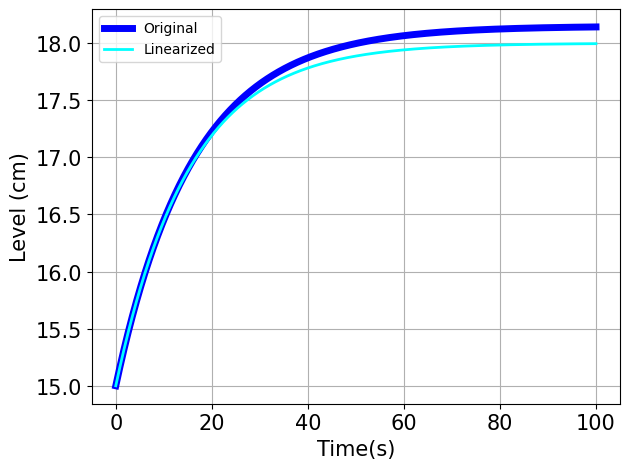

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


fontesize = 15


d_tanque = 4.445;
d_1 = 0.47625;

h = 25;
L_0 = 15;

g = 980;

A = (np.pi*d_tanque**2)/4;
A_1 = (np.pi*d_1**2)/4;

alpha = (A_1/A)*np.sqrt(g/(2*L_0));

beta = 1/A;

t = np.linspace(0, 100, 10000);

N = len(t);
dt = t[2] - t[1];

L_real = np.zeros(N);
L_real[0] = L_0;

d_L = L_real.copy();
d_L[0] = L_real[0] - L_0;


K_m = 4;
F_0 = A_1*np.sqrt(2*g*L_0);

V_0 = F_0/K_m;

F_in = 1.1*F_0*np.ones(N);
delta_F_in = F_in - F_0;


for i in range(0, N-1):
   L_real[i+1] = L_real[i] + (dt/A)*( F_in[i] - (A_1)*np.sqrt(2*g*L_real[i]));
   d_L[i+1] = d_L[i] + dt*(-alpha*d_L[i] + beta*delta_F_in[i]);


L_approx = L_0 + d_L

plt.plot(t, L_real, 'blue', linewidth=5, label = 'Original')
plt.plot(t, L_approx, 'cyan', linewidth=2, label = 'Linearized')
plt.legend()
plt.xlabel('Time(s)', fontsize = fontesize)
plt.ylabel('Level (cm)', fontsize = fontesize)

plt.xticks(fontsize=fontesize)
plt.yticks(fontsize=fontesize)
plt.grid()
plt.tight_layout()


##**Controlando o nível do tanque: Controle de Sistema de Primeira ordem**

Considerando a função de transferência linearizada em torno do ponto de operação

\begin{equation}
    G(s) = \frac{L_1(s)}{V_p(s)} = \frac{0.26}{s + 0.066} = \frac{A}{s + \tau}
\end{equation}

E a função de transferência do controlador PID

\begin{equation}
  C(s) = \frac{K_d s^2 + K_p s + K_I}{s}
\end{equation}

assim, a função de transferência de malha fechada com o controlador se torna

$$
G_{mf}(s) = \frac{ G(s) C(s)}{1 + G(s) C(s)} = \frac{ \frac{A(s^2 K_d + s K_p + K_I)}{s(s+\tau)} } {1  + \frac{A(s^2 K_d + s K_p + K_I)}{s(s+\tau)}}   = \frac{ \frac{1}{AK_d+1}(s^2 + K_p/K_ds + K_I/K_d)}{s^2 + \frac{(AK_p + \tau)}{AK_d+1}s + \frac{AK_I}{AK_d + 1} }
$$

considerando apenas um controlador PI, fazendo $K_d \rightarrow 0$, temos

$$
G_{mf}(s) = \frac{AK_p s + AK_I}{s^2 + (AK_p + \tau)s + AK_I}
$$


Podemos agora utilizar o LGR para calcular o ganho K, então assim temos

Passo 1 e 2:

$$
1 + G(s)H(s) = 1 + \frac{A}{s + \tau} \frac{K_ps + K_I}{s} = 1 + K_p\frac{A(s + \tau_i)}{s(s+\tau)}
$$

Agora os passos do LGR definem


Passo 3: Os lugares a esquerda de um numero impar de polos+zeros é LGR

Passo 4: Polos: 0, $\tau$, Zeros: $\tau_i$

Passo 5: $LS = max(N_p, N_z) = N_p = 2$

Passo 6: Simetria

Passo 7: $N_p - N_z = 2 - 1 = 1$ Polos seguem assíntotas em direção ao infinito


O LGR é enfim mostrado abaixo


![LGR Controle PI](root_locus_PI_control.png)

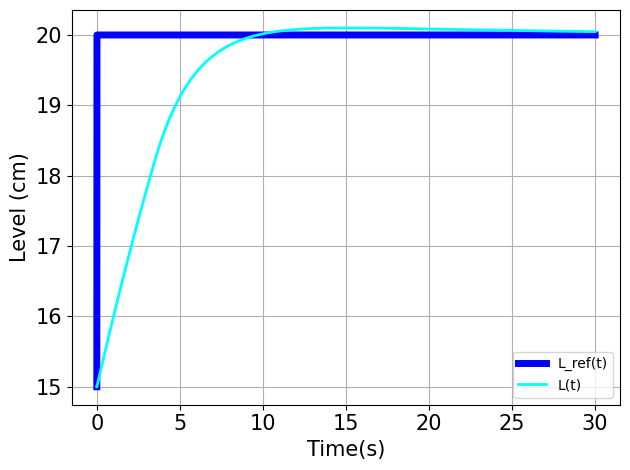

In [ ]:

V_max = 4


# PID Constants
K_p = 1.6
K_d = 0.1
K_I = 0.1




t = np.linspace(0, 30, 10000);

N = len(t);
dt = t[2] - t[1];

L_real = np.zeros(N);
L_real[0] = L_0;

d_L = L_real.copy();
d_L[0] = L_real[0] - L_0;


K_m = 4;
V_0 = A_1*np.sqrt(2*g*L_0)/K_m;


V_in = 1.1*V_0*np.ones(N);
delta_V_in = V_in - V_0;


L_ref = 20*np.ones(N)
L_ref[0] = L_0
d_L_ref = L_ref - L_0

err = np.zeros(N)

err[0] = d_L[0] - d_L_ref[0]

# Ruído Aditivo
# n = 0.002*np.random.randn(N, 1)
n = np.zeros(N)

for i in range(0, N-1):
   err[i+1] = d_L_ref[i] - d_L[i]
   V_in[i] = K_p*err[i+1] + K_I*np.sum(err[:i+1])*dt + K_d*((err[i+1] - err[i])/dt)
   V_sat = np.clip(V_in[i], 0, V_max)
   d_L[i+1] = d_L[i] + dt*(-alpha*d_L[i] + beta*K_m*V_sat)+ n[i]

L_approx = L_0 + d_L


plt.plot(t, L_ref, 'blue', linewidth=5, label = 'L_ref(t)')
plt.plot(t, L_approx, 'cyan', linewidth=2, label = 'L(t)')
plt.legend()
plt.xlabel('Time(s)', fontsize = fontesize)
plt.ylabel('Level (cm)', fontsize = fontesize)

plt.xticks(fontsize=fontesize)
plt.yticks(fontsize=fontesize)
plt.grid()
plt.tight_layout()


##**Simulação na Planta Real**

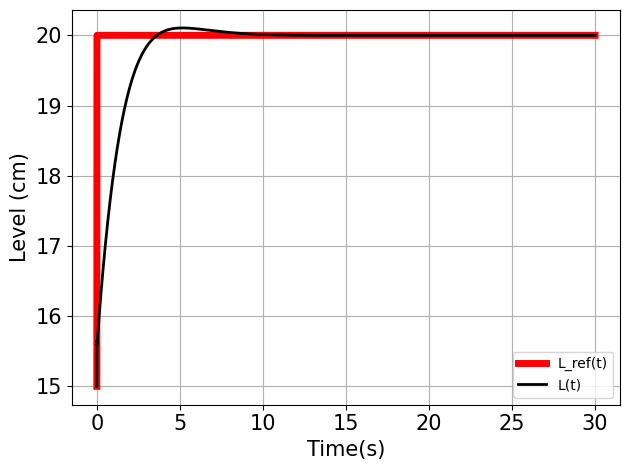

In [ ]:

V_max = 4


# PID Constants
K_p = 5
K_d = 0.5
K_I = 2




t = np.linspace(0, 30, 10000);

N = len(t);
dt = t[2] - t[1];

L = np.zeros(N);
L[0] = L_0;



K_m = 4;

V_in_real = np.zeros(N)

L_ref = 20*np.ones(N)
L_ref[0] = L_0

err = np.zeros(N)

err[0] =  L_ref[0] - L[0]

# Ruído Aditivo
# n = 0.003*np.random.randn(N, 1)
n = np.zeros(N)

for i in range(0, N-1):
   err[i+1] = L_ref[i] - L[i]
   V_in[i] = K_p*err[i+1] + K_I*np.sum(err[:i+1]*dt )+ K_d*((err[i+1] - err[i])/dt)
  #  V_sat = np.clip(V_in[i], 0, V_max)
   V_sat = V_in[i]
   L[i+1] = L[i] + dt*(-(A_1/A)*np.sqrt(2*g*L[i]) + beta*K_m*V_sat)+ n[i]



plt.plot(t, L_ref, 'red', linewidth=5, label = 'L_ref(t)')
plt.plot(t, L, 'black', linewidth=2, label = 'L(t)')
plt.legend()
plt.xlabel('Time(s)', fontsize = fontesize)
plt.ylabel('Level (cm)', fontsize = fontesize)

plt.xticks(fontsize=fontesize)
plt.yticks(fontsize=fontesize)
plt.grid()
plt.tight_layout()
